In [ ]:
# Semiconductor Process SPC Analysis

1 Introduction
2 Process Data Simulation
3 Data Overview
4 SPC Control Chart
5 Tool Variation Analysis
6 Wafer Position Analysis
7 Conclusion


## Introduction

Statistical Process Control (SPC) is widely used in semiconductor manufacturing
to monitor process stability and detect abnormal variations.

This notebook demonstrates a simulated semiconductor process dataset and
applies SPC techniques to analyze process behavior.

The simulation includes several common manufacturing variations:

- Process drift
- Tool-to-tool variation
- Wafer position variation (edge effect)

Python is used to perform statistical analysis and visualization.

In [ ]:
## Process Data Simulation

In this section, a simulated semiconductor process dataset is generated.

The dataset includes:

- **Process Drift**: gradual increase in process mean over time  
- **Tool Variation**: measurement offset between different tools (CVD01 vs CVD02)  
- **Wafer Position Effect**: edge wafers showing slightly lower measurements

These effects are commonly observed in real semiconductor manufacturing processes.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 500
base_mean = 100
sigma = 1.2

data = []

for i in range(n):

    # 1 
    drift = i * 0.01
    
    # 2 機台差異
    tool = np.random.choice(["CVD01","CVD02"])
    
    tool_bias = 0
    if tool == "CVD02":
        tool_bias = 1   # CVD02 偏高
    
    # 3 wafer edge effect
    wafer_position = np.random.choice(["Center","Edge"])
    
    edge_bias = 0
    if wafer_position == "Edge":
        edge_bias = -0.8
    
    measurement = np.random.normal(
        base_mean + drift + tool_bias + edge_bias,
        sigma
    )
    
    data.append([
        i+1,
        tool,
        wafer_position,
        measurement
    ])

df = pd.DataFrame(
    data,
    columns=[
        "Lot_ID",
        "Tool_ID",
        "Wafer_Position",
        "Measurement"
    ]
)

df.to_csv("process_data.csv",index=False)



In [ ]:
## Data Overview

After generating the dataset, we inspect the basic structure
and statistical characteristics of the process data.

Key variables include:
- **Lot_ID** – measurement sequence
- **Tool_ID** – processing equipment used
- **Wafer_Position** – center or edge location
- **Measurement** – simulated process measurement value

In [6]:
df.head()
df.describe()

,Lot_ID,Measurement
count,500.000000,500.000000
mean,250.500000,102.624331
std,144.481833,1.965527
min,1.000000,97.124941
25%,125.750000,101.209184
50%,250.500000,102.637747
75%,375.250000,104.040702
max,500.000000,108.548852


In [ ]:
## SPC Control Chart

A control chart is used to monitor process stability over time.

The control limits are calculated using the standard SPC method:

- **Upper Control Limit (UCL)** = mean + 3σ
- **Lower Control Limit (LCL)** = mean − 3σ

Points outside the control limits may indicate abnormal process behavior
or special causes that require investigation.

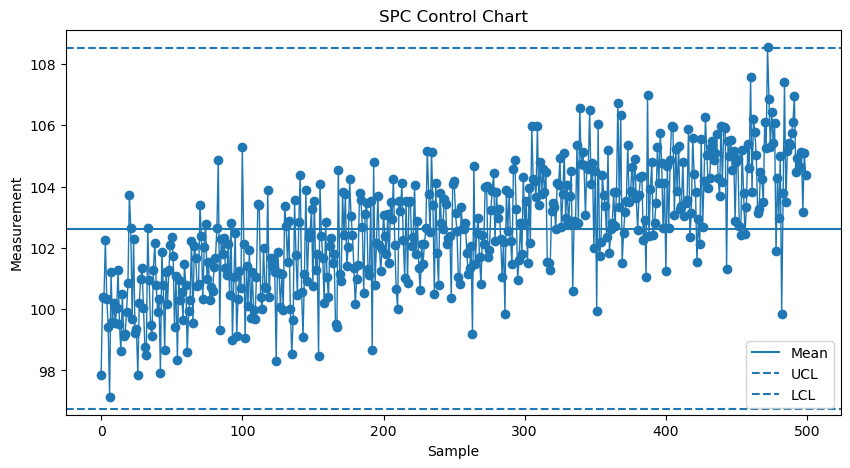

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("process_data.csv")

measurement = df["Measurement"]

mean = measurement.mean()
std = measurement.std()

UCL = mean + 3 * std
LCL = mean - 3 * std

plt.figure(figsize=(10,5))

plt.plot(measurement, marker="o", linewidth=1)

plt.axhline(mean, label="Mean")
plt.axhline(UCL, linestyle="--", label="UCL")
plt.axhline(LCL, linestyle="--", label="LCL")

plt.title("SPC Control Chart")
plt.xlabel("Sample")
plt.ylabel("Measurement")

plt.legend()

plt.savefig("control_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
## Tool Variation Analysis

Different process tools may produce slightly different results
due to calibration differences or hardware variations.

In this section, the measurements from two tools (CVD01 and CVD02)
are compared to evaluate potential tool offsets.

Tool-to-tool variation is an important factor in semiconductor
process control and yield management.

In [9]:
df.groupby("Tool_ID")["Measurement"].mean()


Tool_ID
CVD01    102.163187
CVD02    103.144345
Name: Measurement, dtype: float64

In [ ]:
## Wafer Position Analysis

Wafer position can affect measurement results due to process
non-uniformity across the wafer surface.

Edge regions may experience different process conditions
compared to the center.

This analysis compares measurements between:

- Center wafers
- Edge wafers

In [10]:
df.groupby("Wafer_Position")["Measurement"].mean()

Wafer_Position
Center    103.111845
Edge      102.065678
Name: Measurement, dtype: float64

In [ ]:
## Conclusion

This notebook demonstrates a simplified semiconductor process
analysis using Python.

Key observations include:

- Process drift can gradually shift the process mean over time
- Tool-to-tool variation can introduce measurement offsets
- Wafer edge effects can create systematic variation

SPC techniques such as control charts and statistical analysis
are useful tools for monitoring and improving manufacturing processes.